In [141]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
import logging

# Import your custom modules
from heston_model import hCommModel
from heston_calibration import hCommCalibrator
from heston_pricer import hCommPricer

# Plot style 
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Configure logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

print("All imports are good")

All imports are good


In [142]:
vol_surface = pd.read_excel(r'C:/Users/Krupam/Downloads/SPY_Calibration_Template.xlsx', sheet_name='Vol_Matrix', index_col=0)
market_data = pd.read_excel(r'C:/Users/Krupam/Downloads/SPY_Calibration_Template.xlsx', sheet_name='Market_Data')

print("Volatility Surface Shape:", vol_surface.shape)
print("\nMaturities (years):", vol_surface.index.values[:5])
print("Moneyness levels:", vol_surface.columns.values[:5])
print("\nVolatility Surface (first 5x5):")
print(vol_surface.iloc[:5, :5])

Volatility Surface Shape: (21, 23)

Maturities (years): [0.08761123 0.12594114 0.22176591 0.29842574 0.47091034]
Moneyness levels: [40 45 50 55 60]

Volatility Surface (first 5x5):
                 40        45        50        55        60
Year_Frac                                                  
0.087611   0.854107  0.801123  0.749007  0.693375  0.630611
0.125941   0.792424  0.745826  0.687665  0.637167  0.583608
0.221766   0.691275  0.642817  0.591062  0.541843  0.501652
0.298426   0.650459  0.603098  0.553366  0.507459  0.469908
0.470910   0.564138  0.516737  0.485095  0.454576  0.426959


In [143]:
S0 = market_data['S0'].iloc[0]  # Spot price
r = market_data['Risk_Free_Rate'].iloc[0]  # Risk-free rate
q = market_data['Div_Yield'].iloc[0]  # Dividend yield (convenience yield for commodities)

print(f"Market Parameters:")
print(f" Spot Price (S0): ${S0:.2f}")
print(f" Risk-Free Rate (r): {r:.4f} ({r*100:.2f}%)")
print(f" Dividend Yield (q): {q:.4f} ({q*100:.2f}%)")

Market Parameters:
 Spot Price (S0): $520.00
 Risk-Free Rate (r): 0.0492 (4.92%)
 Dividend Yield (q): -0.0145 (-1.45%)


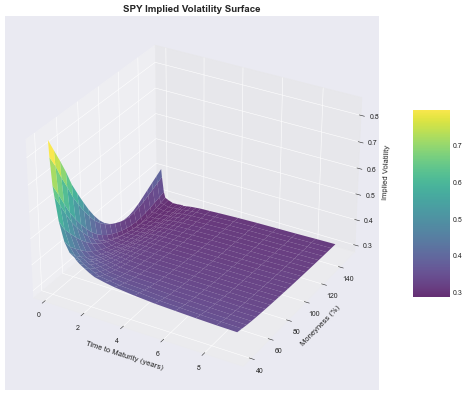

3D volatility surface plotted


In [144]:
# Visualize the 3D volatility surface
fig = plt.figure(figsize=(14, 8), dpi=50) # I had to reduce the dpi cause github would only let me upload files under 1 MB. Sorry if its too small. 
ax = fig.add_subplot(111, projection='3d')

# Create meshgrid
T_grid, K_grid = np.meshgrid(vol_surface.index, vol_surface.columns)
vol_grid = vol_surface.values.T

# Plot surface
surf = ax.plot_surface(T_grid, K_grid, vol_grid, cmap='viridis', alpha=0.8, edgecolor='none')

ax.set_xlabel('Time to Maturity (years)', fontsize=11)
ax.set_ylabel('Moneyness (%)', fontsize=11)
ax.set_zlabel('Implied Volatility', fontsize=11)
ax.set_title('SPY Implied Volatility Surface', fontsize=14, fontweight='bold')

fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)
plt.tight_layout()
plt.show()

print("3D volatility surface plotted")

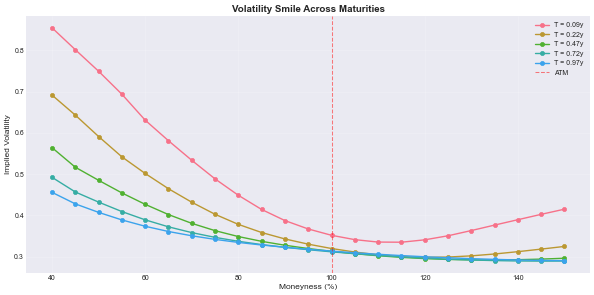

Volatility smiles plotted


In [145]:
# Plot volatility smile for different maturities
fig, ax = plt.subplots(figsize=(12, 6), dpi=50)

selected_maturities = [0.09, 0.22, 0.47, 0.72, 0.97] 

for T in selected_maturities:
    # Find closest maturity in data
    idx = np.argmin(np.abs(vol_surface.index - T))
    actual_T = vol_surface.index[idx]
    
    vols = vol_surface.iloc[idx]
    ax.plot(vols.index, vols.values, marker='o', label=f'T = {actual_T:.2f}y', linewidth=2)

ax.axvline(x=100, color='red', linestyle='--', alpha=0.5, label='ATM')
ax.set_xlabel('Moneyness (%)', fontsize=12)
ax.set_ylabel('Implied Volatility', fontsize=12)
ax.set_title('Volatility Smile Across Maturities', fontsize=14, fontweight='bold')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Volatility smiles plotted")

In [146]:
# Initial Heston parameters
initial_params = {
    'kappa': 2.0, # Mean reversion speed
    'theta': 0.04, # Long-term variance
    'xi': 0.3, # Vol of vol
    'rho': -0.7, # Correlation (negative for equities)
    'v0': 0.04} # Initial variance

model = hCommModel(initial_params)

print("Initial Heston Parameters:")
for key, val in initial_params.items():
    print(f" {key}: {val}")

feller_lhs = 2 * model.kappa * model.theta
feller_rhs = model.xi ** 2
print(f"\nFeller Condition Check: 2*kappa*theta = {feller_lhs:.4f} {'>' if feller_lhs > feller_rhs else '<'} xi^2 = {feller_rhs:.4f}")
print(f"Status: {'Satisfied' if feller_lhs >= feller_rhs else ' Violated'}")

2026-01-30 20:33:15,953 - INFO - Initialized hCommModel: kappa=2.00000, theta=0.04000, xi=0.30000, rho=-0.70000, v0=0.04000


Initial Heston Parameters:
 kappa: 2.0
 theta: 0.04
 xi: 0.3
 rho: -0.7
 v0: 0.04

Feller Condition Check: 2*kappa*theta = 0.1600 > xi^2 = 0.0900
Status: Satisfied


In [147]:
# Price options across a range of strikes using FFT
T_test = 0.5 
strikes = np.linspace(S0 * 0.8, S0 * 1.2, 50)

# Price using Carr-Madan FFT
fft_prices = model.carr_madan_call_prices(T_test, S0, r, q, strikes, alpha=1.5, N=4096, eta=0.25)

# Price using traditional trapezoidal integration (a bit slower but accurate)
trap_prices = model.h_call_prices_trapezoid(T_test, S0, r, q, strikes[::5]) 

print(f"Priced {len(strikes)} options using FFT in seconds")
print(f"Sample prices (first 5 strikes):")
for i in range(5):
    print(f"  Strike ${strikes[i]:.2f}: ${fft_prices[i]:.4f}")

Priced 50 options using FFT in seconds
Sample prices (first 5 strikes):
  Strike $416.00: $120.1247
  Strike $420.24: $116.2468
  Strike $424.49: $112.3950
  Strike $428.73: $108.5714
  Strike $432.98: $104.7780


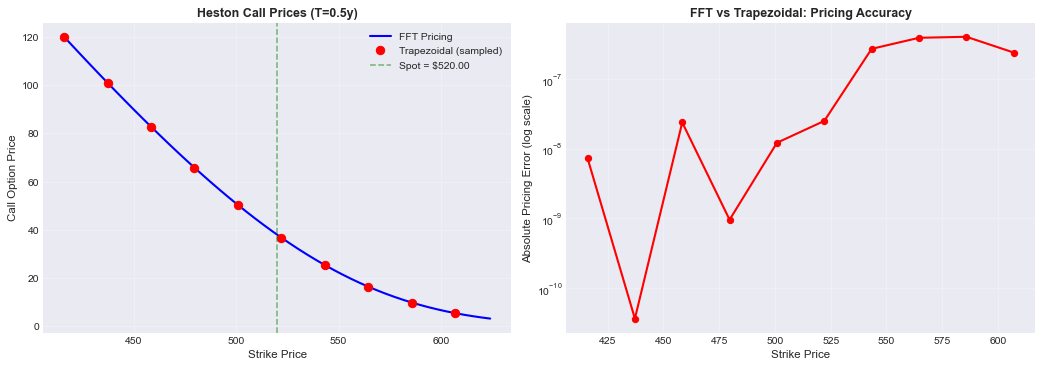


Max pricing error: $0.000000
Mean pricing error: $0.000000
FFT pricing sucessful


In [148]:
# Plot FFT vs Trapezoidal pricing comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=75)

# Left: Price curves
ax1.plot(strikes, fft_prices, 'b-', linewidth=2, label='FFT Pricing')
ax1.plot(strikes[::5], trap_prices, 'ro', markersize=8, label='Trapezoidal (sampled)')
ax1.axvline(x=S0, color='green', linestyle='--', alpha=0.5, label=f'Spot = ${S0:.2f}')
ax1.set_xlabel('Strike Price', fontsize=11)
ax1.set_ylabel('Call Option Price', fontsize=11)
ax1.set_title(f'Heston Call Prices (T={T_test}y)', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right: Pricing errors
errors = np.abs(fft_prices[::5] - trap_prices)
ax2.semilogy(strikes[::5], errors, 'ro-', linewidth=2, markersize=6)
ax2.set_xlabel('Strike Price', fontsize=11)
ax2.set_ylabel('Absolute Pricing Error (log scale)', fontsize=11)
ax2.set_title('FFT vs Trapezoidal: Pricing Accuracy', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nMax pricing error: ${errors.max():.6f}")
print(f"Mean pricing error: ${errors.mean():.6f}")
print("FFT pricing sucessful")

In [149]:
calibrator = hCommCalibrator(model)

T_calib = 0.47  

# Adjust bounds for equity (vs commodity defaults)
equity_bounds = {
    "kappa": (0.5, 5.0), # Lower for equities
    "xi": (0.1, 1.5), # Lower vol of vol
    "rho": (-0.95, -0.3), # Strongly negative for equities
    "v0": (0.001, 0.5), # Initial variance
    "theta_scale": (0.1, 2.0) # Ensures Feller
}

print(f"Starting calibration for T = {T_calib}y\n")

2026-01-30 20:33:16,641 - INFO - Initialized hCommCalibrator


Starting calibration for T = 0.47y



In [150]:
# Run single-T calibration
result_single = calibrator.calibrate_single_T(df_vol_surface=vol_surface, T=T_calib, S0=S0, r=r, q=q, 
                                              alpha=1.5, N_fft=4096, eta=0.25, bounds=equity_bounds)

if result_single['success']:
    print("Calibration successful!")
    print(f"\nCalibrated Parameters:")
    for key, val in result_single['params'].items():
        print(f"  {key}: {val:.5f}")
    print(f"\nFinal MSE: {result_single['mse']:.2e}")
    print(f"RMSE: ${result_single['pricing_errors']['rmse']:.4f}")
else:
    print("Calibration failed:", result_single.get('message', 'Unknown error'))

2026-01-30 20:33:16,678 - INFO - Starting calibration for T=0.4700y, S0=520.0000
2026-01-30 20:33:16,680 - WARNING - Feller condition violated: 2*kappa*theta (0.04500) < xi^2 (0.09000). Variance process may reach zero.
2026-01-30 20:33:16,681 - INFO - Initialized hCommModel: kappa=2.00000, theta=0.01125, xi=0.30000, rho=-0.70000, v0=0.04000
2026-01-30 20:33:16,690 - WARNING - Feller condition violated: 2*kappa*theta (0.04500) < xi^2 (0.09000). Variance process may reach zero.
2026-01-30 20:33:16,693 - INFO - Initialized hCommModel: kappa=2.00000, theta=0.01125, xi=0.30000, rho=-0.70000, v0=0.04000


2026-01-30 20:33:16,700 - WARNING - Feller condition violated: 2*kappa*theta (0.04500) < xi^2 (0.09000). Variance process may reach zero.
2026-01-30 20:33:16,702 - INFO - Initialized hCommModel: kappa=2.00000, theta=0.01125, xi=0.30000, rho=-0.70000, v0=0.04000
2026-01-30 20:33:16,712 - WARNING - Feller condition violated: 2*kappa*theta (0.04500) < xi^2 (0.09000). Variance process may reach zero.
2026-01-30 20:33:16,714 - INFO - Initialized hCommModel: kappa=2.00000, theta=0.01125, xi=0.30000, rho=-0.70000, v0=0.04000
2026-01-30 20:33:16,723 - WARNING - Feller condition violated: 2*kappa*theta (0.04500) < xi^2 (0.09000). Variance process may reach zero.
2026-01-30 20:33:16,726 - INFO - Initialized hCommModel: kappa=2.00000, theta=0.01125, xi=0.30000, rho=-0.70000, v0=0.04000
2026-01-30 20:33:16,734 - WARNING - Feller condition violated: 2*kappa*theta (0.04500) < xi^2 (0.09000). Variance process may reach zero.
2026-01-30 20:33:16,738 - INFO - Initialized hCommModel: kappa=2.00000, thet

Calibration successful:
Iterations: 105
Total Error: 4.18491e-02.

Parameters:
kappa: 5.00000, theta: 0.14804, xi: 1.09241, rho: -0.35233, v0: 0.03928

Market vs Model price differences (%):
Moneyness 40.00%: Difference = -0.0751%
Moneyness 45.00%: Difference = -0.0906%
Moneyness 50.00%: Difference = -0.1296%
Moneyness 55.00%: Difference = -0.1625%
Moneyness 60.00%: Difference = -0.1811%
Moneyness 65.00%: Difference = -0.1656%
Moneyness 70.00%: Difference = -0.1047%
Moneyness 75.00%: Difference = 0.0033%
Moneyness 80.00%: Difference = 0.1329%
Moneyness 85.00%: Difference = 0.2396%
Moneyness 90.00%: Difference = 0.2686%
Moneyness 95.00%: Difference = 0.1735%
Moneyness 100.00%: Difference = -0.0440%
Moneyness 105.00%: Difference = -0.3207%
Moneyness 110.00%: Difference = -0.5608%
Moneyness 115.00%: Difference = -0.6420%
Moneyness 120.00%: Difference = -0.4264%
Moneyness 125.00%: Difference = 0.1418%
Moneyness 130.00%: Difference = 0.9775%
Moneyness 135.00%: Difference = 1.9577%
Moneyness

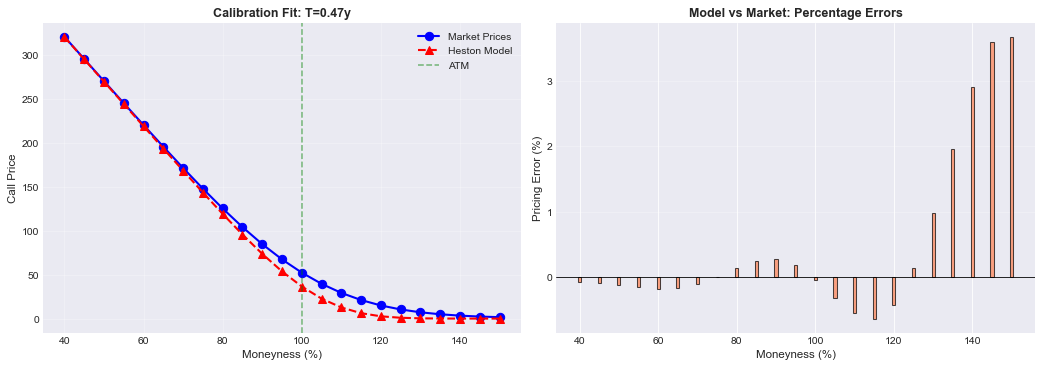

Calibration quality visualization complete


In [153]:
# Visualize calibration fit
if result_single['success']:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=75)
    
    moneyness, sigma_market = calibrator.get_volatility_slice(vol_surface, T_calib)
    strikes = moneyness * S0 / 100
    
    market_prices = calibrator.bs_call_prices(S0, strikes, T_calib, r, q, sigma_market)
    
    model_prices = model.carr_madan_call_prices(T_calib, S0, r, q, strikes)
    
    # Left: Price comparison
    ax1.plot(moneyness, market_prices, 'bo-', linewidth=2, markersize=8, label='Market Prices')
    ax1.plot(moneyness, model_prices, 'r^--', linewidth=2, markersize=8, label='Heston Model')
    ax1.axvline(x=100, color='green', linestyle='--', alpha=0.5, label='ATM')
    ax1.set_xlabel('Moneyness (%)', fontsize=11)
    ax1.set_ylabel('Call Price', fontsize=11)
    ax1.set_title(f'Calibration Fit: T={T_calib}y', fontsize=12, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Right: Percentage errors
    pct_errors = result_single['pricing_errors']['percentage']
    ax2.bar(moneyness, pct_errors, color='coral', alpha=0.7, edgecolor='black')
    ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
    ax2.set_xlabel('Moneyness (%)', fontsize=11)
    ax2.set_ylabel('Pricing Error (%)', fontsize=11)
    ax2.set_title('Model vs Market: Percentage Errors', fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    print("Calibration quality visualization complete")

In [152]:
# Reset model to initial guess for multi-T calibration
model = hCommModel(initial_params)
calibrator = hCommCalibrator(model)

# 3M, 6M, 9M, 1Y
Ts_multi = [0.22, 0.47, 0.72, 0.97]

# Give more weight to middle maturities
weights = [1.0, 1.5, 1.5, 1.0] 

print(f"Starting multi-T calibration for T = {Ts_multi}\n")

2026-01-30 20:33:23,471 - INFO - Initialized hCommModel: kappa=2.00000, theta=0.04000, xi=0.30000, rho=-0.70000, v0=0.04000
2026-01-30 20:33:23,473 - INFO - Initialized hCommCalibrator


Starting multi-T calibration for T = [0.22, 0.47, 0.72, 0.97]



In [134]:
# Run multi-T calibration
result_multi = calibrator.calibrate_multi_T(df_vol_surface=vol_surface, Ts=Ts_multi, S0=S0, r=r, q=q, 
                                            weights=weights, alpha=1.5, N_fft=4096, eta=0.2)

if result_multi['success']:
    print("Multi-T calibration good")
    print(f"\nCalibrated Parameters:")
    for key, val in result_multi['params'].items():
        print(f"  {key}: {val:.5f}")
    print(f"\nFinal Weighted MSE: {result_multi['mse']:.2e}")
else:
    print("Multi-T calibration failed:", result_multi.get('message', 'Unknown error'))

2026-01-30 20:32:55,829 - INFO - Starting multi-T calibration: 4 Ts
2026-01-30 20:32:55,831 - WARNING - Feller condition violated: 2*kappa*theta (0.04500) < xi^2 (0.09000). Variance process may reach zero.
2026-01-30 20:32:55,831 - INFO - Initialized hCommModel: kappa=2.00000, theta=0.01125, xi=0.30000, rho=-0.70000, v0=0.04000
2026-01-30 20:32:55,847 - WARNING - Feller condition violated: 2*kappa*theta (0.04500) < xi^2 (0.09000). Variance process may reach zero.
2026-01-30 20:32:55,848 - INFO - Initialized hCommModel: kappa=2.00000, theta=0.01125, xi=0.30000, rho=-0.70000, v0=0.04000
2026-01-30 20:32:55,861 - WARNING - Feller condition violated: 2*kappa*theta (0.04500) < xi^2 (0.09000). Variance process may reach zero.
2026-01-30 20:32:55,862 - INFO - Initialized hCommModel: kappa=2.00000, theta=0.01125, xi=0.30000, rho=-0.70000, v0=0.04000
2026-01-30 20:32:55,875 - WARNING - Feller condition violated: 2*kappa*theta (0.04500) < xi^2 (0.09000). Variance process may reach zero.
2026-01-

Multi-T calibration successful:
Calibrated to 4 Ts: [0.22, 0.47, 0.72, 0.97]
Iterations: 79
Final weighted MSE: 4.24253e-02

Parameters:
kappa: 5.00024, theta: 0.10106, xi: 0.98672, rho: -0.35047, v0: 0.11462

Multi-T calibration good

Calibrated Parameters:
  kappa: 5.00024
  theta: 0.10106
  xi: 0.98672
  rho: -0.35047
  v0: 0.11462

Final Weighted MSE: 4.24e-02


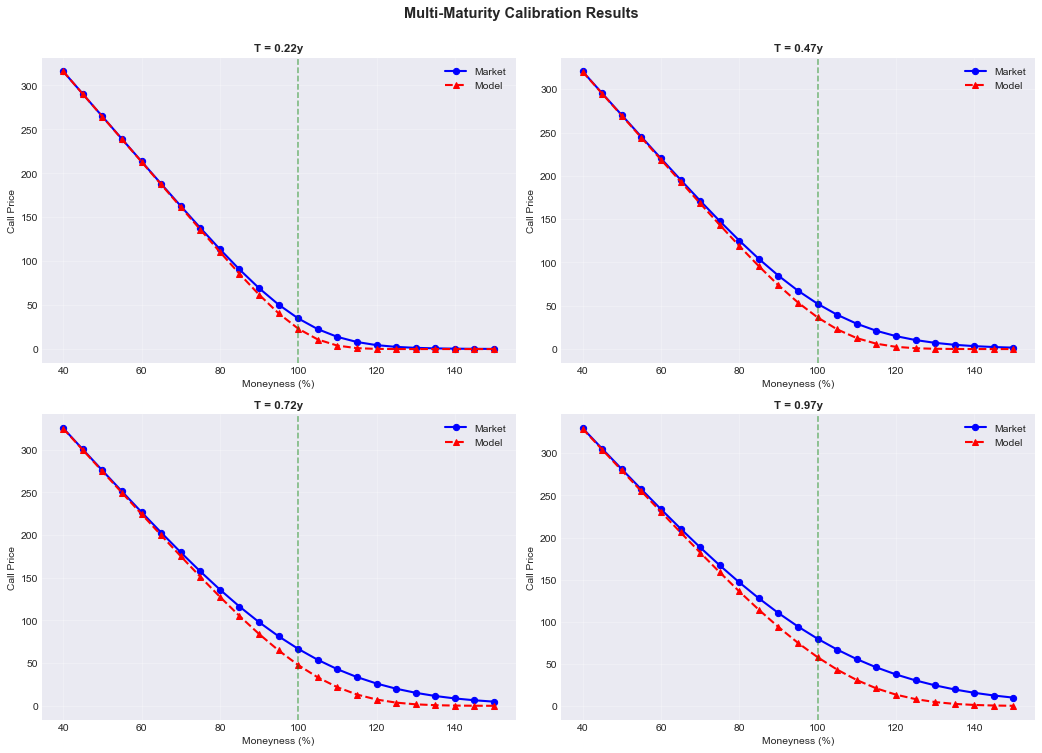

Multi-T calibration quality visualization complete


In [155]:
# Visualize multi-T calibration fit
if result_multi['success']:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10), dpi=75)
    axes = axes.flatten()
    
    for idx, T in enumerate(Ts_multi):
        ax = axes[idx]
        
        moneyness, sigma_market = calibrator.get_volatility_slice(vol_surface, T)
        strikes = moneyness * S0 / 100
        market_prices = calibrator.bs_call_prices(S0, strikes, T, r, q, sigma_market)
        
        model_prices = model.carr_madan_call_prices(T, S0, r, q, strikes)
        
        ax.plot(moneyness, market_prices, 'bo-', linewidth=2, markersize=6, label='Market')
        ax.plot(moneyness, model_prices, 'r^--', linewidth=2, markersize=6, label='Model')
        ax.axvline(x=100, color='green', linestyle='--', alpha=0.5)
        ax.set_xlabel('Moneyness (%)', fontsize=10)
        ax.set_ylabel('Call Price', fontsize=10)
        ax.set_title(f'T = {T:.2f}y', fontsize=11, fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    fig.suptitle('Multi-Maturity Calibration Results', fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()
    
    print("Multi-T calibration quality visualization complete")

In [136]:
sim_params = {
    'S0': S0, # Initial spot
    'T': 1.0, # 1 year simulation
    'r': r, # Risk-free rate
    'q': q, # Convenience yield
    'M': 5000, # Number of paths
    'N': 252,  # Daily steps (252 trading days)
    'seed': 42, # For reproducibility
    'alpha': 0.0,  # No mean reversion overlay
    'mu': 0.0,
    'A': 0.0, # No seasonality
    'phi': 0.0}

class SimConfig:
    def __init__(self, **kwargs):
        for key, value in kwargs.items():
            setattr(self, key, value)

config = SimConfig(**sim_params)

# Run simulation
spot_paths, var_paths = model.simulate(config)

print(f"\n Simulation complete")
print(f"  Spot paths shape: {spot_paths.shape}")
print(f"  Variance paths shape: {var_paths.shape}")
print("Simulation Configuration:")
print(f"  Paths: {sim_params['M']:,}")
print(f"  Time Steps: {sim_params['N']}")
print(f"  Maturity: {sim_params['T']} years")
print(f"\nUsing calibrated Heston parameters from multi-T calibration")


 Simulation complete
  Spot paths shape: (253, 5000)
  Variance paths shape: (253, 5000)
Simulation Configuration:
  Paths: 5,000
  Time Steps: 252
  Maturity: 1.0 years

Using calibrated Heston parameters from multi-T calibration


In [137]:
# BIG THING: The simulate method signature may need adjustment based on your actual implementation

# Run simulation (adjust based on your actual simulate() signature)
try:
    # Try using the config object if it works
    config = type('SimConfig', (), sim_params)()
    spot_paths, var_paths = model.simulate(config)
except:
    print("Using fallback simulation method")
    # You may need to adjust this based on your actual implementation
    spot_paths, var_paths = model.simulate(S0=sim_params['S0'], T=sim_params['T'], r=sim_params['r'], q=sim_params['q'], 
                                           npaths=sim_params['M'], nsteps=sim_params['N'], seed=sim_params['seed'])

print(f"\n Simulation complete")
print(f"  Spot paths shape: {spot_paths.shape}")
print(f"  Variance paths shape: {var_paths.shape}")
print(f"\nTerminal Statistics:")
print(f"  Mean: ${spot_paths[-1].mean():.2f}")
print(f"  Std Dev: ${spot_paths[-1].std():.2f}")
print(f"  Min: ${spot_paths[-1].min():.2f}")
print(f"  Max: ${spot_paths[-1].max():.2f}")


 Simulation complete
  Spot paths shape: (253, 5000)
  Variance paths shape: (253, 5000)

Terminal Statistics:
  Mean: $555.91
  Std Dev: $173.26
  Min: $84.62
  Max: $1693.57


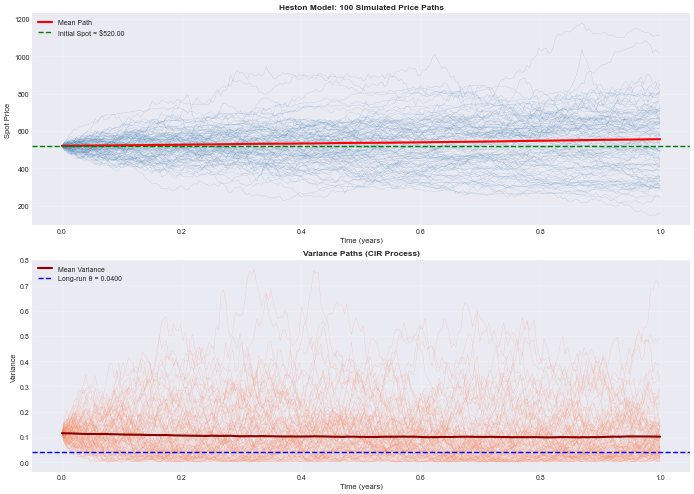

Path simulation visualized


In [156]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), dpi=50)

time_grid = np.linspace(0, sim_params['T'], sim_params['N'] + 1)

# Spot price paths
n_display = 100 
for i in range(n_display):
    ax1.plot(time_grid, spot_paths[:, i], alpha=0.3, linewidth=0.5, color='steelblue')

# Add mean path
mean_path = spot_paths.mean(axis=1)
ax1.plot(time_grid, mean_path, 'r-', linewidth=3, label='Mean Path')
ax1.axhline(y=S0, color='green', linestyle='--', linewidth=2, label=f'Initial Spot = ${S0:.2f}')

ax1.set_xlabel('Time (years)', fontsize=11)
ax1.set_ylabel('Spot Price', fontsize=11)
ax1.set_title(f'Heston Model: {n_display} Simulated Price Paths', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Bottom: Variance paths
for i in range(n_display):
    ax2.plot(time_grid, var_paths[:, i], alpha=0.3, linewidth=0.5, color='coral')

mean_var = var_paths.mean(axis=1)
ax2.plot(time_grid, mean_var, 'darkred', linewidth=3, label='Mean Variance')
ax2.axhline(y=model.theta, color='blue', linestyle='--', linewidth=2, label=f'Long-run θ = {model.theta:.4f}')

ax2.set_xlabel('Time (years)', fontsize=11)
ax2.set_ylabel('Variance', fontsize=11)
ax2.set_title(f'Variance Paths (CIR Process)', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Path simulation visualized")

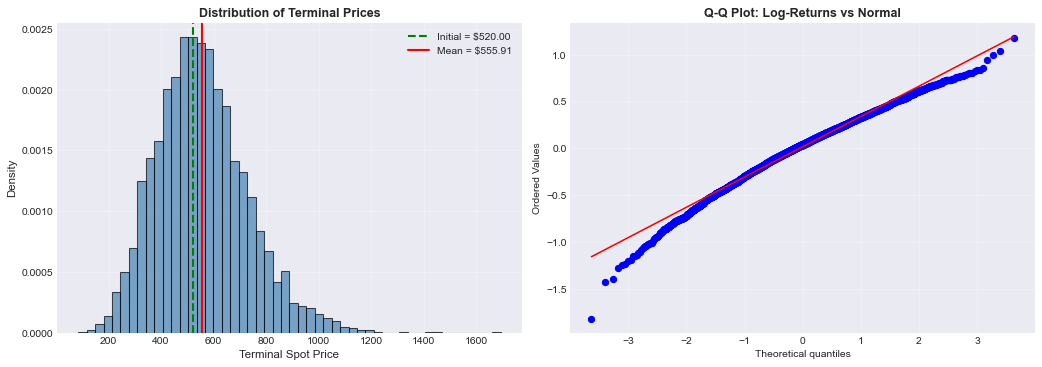


Log-Return Statistics:
 Mean: 0.0166
 Std Dev: 0.3243
 Skewness: -0.4615
 Kurtosis: 0.6168


In [159]:
# Terminal distribution analysis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=75)

# Left: Histogram
ax1.hist(spot_paths[-1], bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='black')
ax1.axvline(x=S0, color='green', linestyle='--', linewidth=2, label=f'Initial = ${S0:.2f}')
ax1.axvline(x=spot_paths[-1].mean(), color='red', linestyle='-', linewidth=2, label=f'Mean = ${spot_paths[-1].mean():.2f}')
ax1.set_xlabel('Terminal Spot Price', fontsize=11)
ax1.set_ylabel('Density', fontsize=11)
ax1.set_title('Distribution of Terminal Prices', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right: Q-Q plot to check normality of log-returns
from scipy.stats import probplot
log_returns = np.log(spot_paths[-1] / S0)
probplot(log_returns, dist="norm", plot=ax2)
ax2.set_title('Q-Q Plot: Log-Returns vs Normal', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nLog-Return Statistics:")
print(f" Mean: {log_returns.mean():.4f}")
print(f" Std Dev: {log_returns.std():.4f}")
print(f" Skewness: {pd.Series(log_returns).skew():.4f}")
print(f" Kurtosis: {pd.Series(log_returns).kurtosis():.4f}")

In [140]:
pricer = hCommPricer(model)

T_exotic = 0.5 # 6 months
K_exotic = S0 # ATM strike

print("Exotic Options Pricing Demo")
print("="*60)
print(f"Underlying: ${S0:.2f}")
print(f"Strike: ${K_exotic:.2f}")
print(f"Maturity: {T_exotic} years")
print(f"Risk-free rate: {r:.4f}")
print(f"Dividend yield: {q:.4f}")
print("="*60)

2026-01-30 20:33:15,119 - INFO - Initialized HP-commodities with model: hCommModel


Exotic Options Pricing Demo
Underlying: $520.00
Strike: $520.00
Maturity: 0.5 years
Risk-free rate: 0.0492
Dividend yield: -0.0145
